<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_20_Seaborn Intro.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Top Companies Bar Plot (2.20.1)

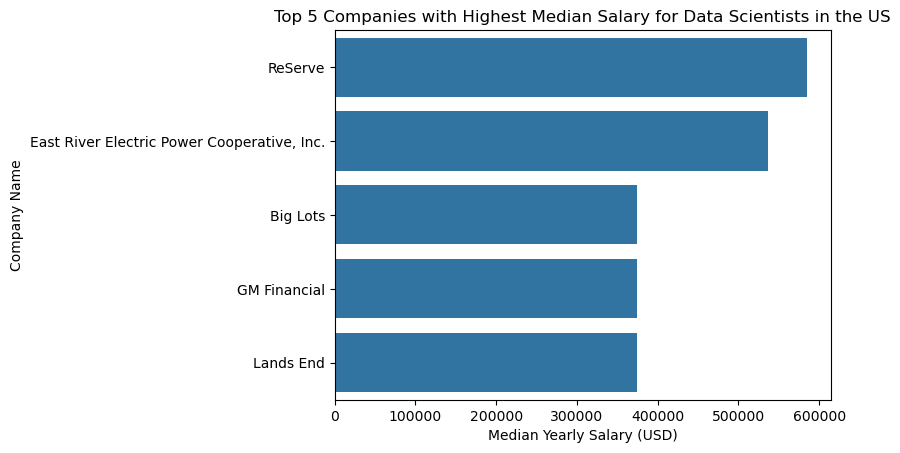

In [3]:
import seaborn as sns
df_DS = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset='salary_year_avg')
company_grouped = df_DS.groupby('company_name')['salary_year_avg'].median().sort_values(ascending=False)
top5 = company_grouped.head(5).reset_index()
sns.barplot(data=top5, x='salary_year_avg', y='company_name')
plt.title('Top 5 Companies with Highest Median Salary for Data Scientists in the US')
plt.xlabel('Median Yearly Salary (USD)')
plt.ylabel('Company Name')
plt.show()

---

## 🟨 Data Scientist Salary Histogram (2.20.2)

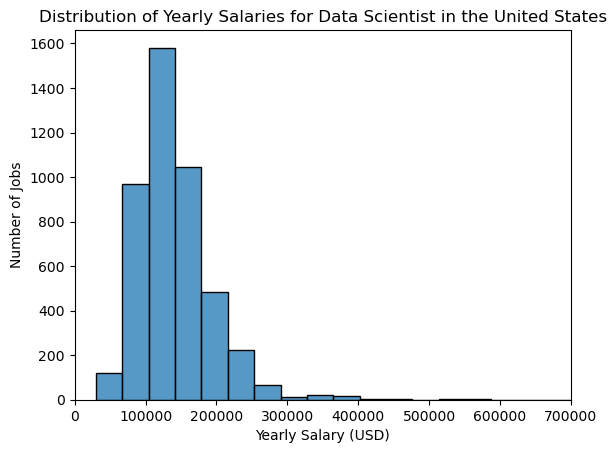

In [ ]:
df_DS_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Scientist')].dropna(subset='salary_year_avg')
sns.histplot(data=df_DS_US['salary_year_avg'], bins=25)
plt.xlim(0, 700_000)
plt.title('Distribution of Yearly Salaries for Data Scientist in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
plt.show()

---

## 🟨 Data Roles Salary Box Plot (2.20.3)

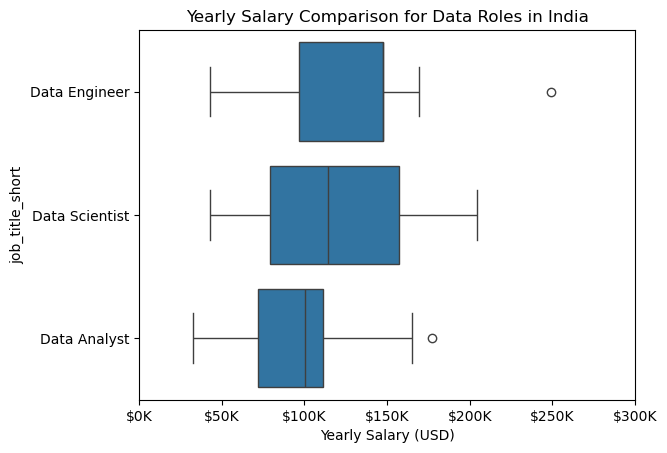

In [13]:
# Code Needed
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_India = df[(df['job_country'] == 'India') & (df['job_title_short'].isin(job_titles))].dropna(subset='salary_year_avg')

sns.boxplot(data=df_India, x = 'salary_year_avg', y='job_title_short')

ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0, 300000)
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.show()


---

## 🟨 Salary Distribution for United States (2.20.4)

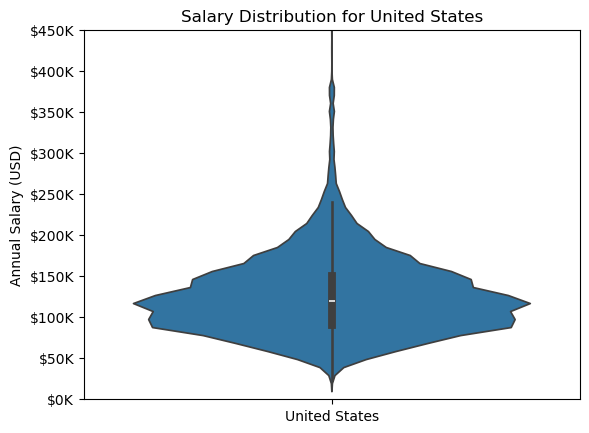

In [15]:
df_DS = df[df['job_title_short'] == 'Data Scientist'].dropna(subset='salary_year_avg')
df_DS_US = df[df['job_country'] == 'United States']

sns.violinplot(data=df_DS_US, x = 'job_country', y='salary_year_avg')
ticks_y = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().yaxis.set_major_formatter(ticks_y)

plt.title('Salary Distribution for United States')
plt.xlabel('')
plt.ylabel('Annual Salary (USD)')
plt.ylim(0, 450000)
plt.show()

---